# Experiment 02 — PdO Analysis

This notebook processes `Processed_data_inputs/experiment02/raw data.xlsx`, the first delivered slice of the PdO Sobol-V03 design from `new_experiment/new_experiment.ipynb`.

Sobol-V03 specifies **23 base runs × 3 replicates = 69 rows** for PdO. The raw file we have contains the first **10 base runs × 3 replicates = 30 rows**, so this analysis works with that completed portion.

Pipeline:
1. Reproduce the Sobol-V03 PdO design (seed=20) and confirm the 30 received rows match the first 10 base runs.
2. Preliminary analysis: failure rate (Contact Fail), distributions, condition-level summaries.
3. ANOVA on Hall mobility against the 10 process factors.
4. Coefficient of variation across replicates.
5. Linear regression validation (LOO-CV, given the small sample size).

Outputs are saved to `repository_dmref/output/experiment02/`.

In [1]:
import os, sys, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import qmc
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Anchor at repo root so relative paths work regardless of where Jupyter starts.
REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)

RAW_PATH = 'Processed_data_inputs/experiment02/raw data.xlsx'
OUT_DIR  = 'output/experiment02'
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
print('Working dir:', os.getcwd())
print('Outputs ->', OUT_DIR)

Working dir: /data/zhq7531/IDEAL/DMREF/repository_dmref
Outputs -> output/experiment02


## 1. Reproduce the Sobol-V03 PdO design and identify the completed portion

We re-run the exact V03 generator (`GLOBAL_SEED=20`, `PDO_BATCHES={'Batch 1': 23, 'Batch 2': 0}`, 3 replicates) and compare row-by-row with the raw file.

In [2]:
GLOBAL_SEED = 20
PDO_BATCHES = {'Batch 1': 23, 'Batch 2': 0}
NUM_REPLICATES = 3

PDO_CONFIG = {
    'Dep Power (W)':      {'min': 0.0,   'max': 40.0,  'decimals': 0},
    'O2 Flow (sccm)':     {'gap_prob': 0, 'gap_val': 0.3, 'min': 0.3, 'max': 20.0, 'decimals': 1},
    'Dep Press (mTorr)':  {'min': 2.0,   'max': 10.0,  'decimals': 1},
    'Dep Temp (°C)':      [25.0, 425.0],
    'Ox Temp (°C)':       {'min': 200.0, 'max': 800.0, 'decimals': 1},
    'Ox Press (atm)':     [0.02, 1.0],
    'Ox Time (min)':      {'min': 0.0,   'max': 120.0, 'decimals': 1},
    'Vac Ann Temp (°C)':  {'min': 25.0,  'max': 800.0, 'decimals': 1},
    'Vac Ann Time (min)': {'min': 0.0,   'max': 120.0, 'decimals': 1},
    'Dep Thickness (nm)': {'min': 1.0,   'max': 10.0,  'decimals': 1},
}

def map_parameter(u_val, settings):
    if isinstance(settings, list):
        idx = min(int(u_val * len(settings)), len(settings) - 1)
        return settings[idx]
    if 'gap_prob' in settings:
        if u_val < settings['gap_prob']:
            val = settings['gap_val']
        else:
            scaled = (u_val - settings['gap_prob']) / (1.0 - settings['gap_prob'])
            val = settings['min'] + scaled * (settings['max'] - settings['min'])
    else:
        val = settings['min'] + u_val * (settings['max'] - settings['min'])
    return round(val, settings.get('decimals', 1))

def generate_doe(num_samples, config, sampler=None, seed=None):
    names = list(config.keys())
    if sampler is None:
        sampler = qmc.Sobol(d=len(names), scramble=True, seed=seed)
    rows = []
    while len(rows) < num_samples:
        batch = sampler.random(n=num_samples * 5)
        for u in batch:
            row = {n: map_parameter(u[i], config[n]) for i, n in enumerate(names)}
            rows.append([row[n] for n in names])
            if len(rows) == num_samples:
                break
    return pd.DataFrame(rows, columns=names), sampler

def add_replicates(df, k):
    df = df.copy()
    df.insert(0, 'Base_Run_ID', range(1, len(df) + 1))
    df = df.loc[df.index.repeat(k)].reset_index(drop=True)
    df.insert(1, 'Replicate', df.groupby('Base_Run_ID').cumcount() + 1)
    return df

# Generate the full V03 plan (23 conditions x 3 replicates)
all_batches, sampler = [], None
for name, n in PDO_BATCHES.items():
    if n <= 0:
        continue
    df_b, sampler = generate_doe(n, PDO_CONFIG, sampler=sampler, seed=GLOBAL_SEED)
    df_b['Batch'] = name
    all_batches.append(df_b)
df_pdo_plan = pd.concat(all_batches, ignore_index=True)
df_pdo_plan_full = add_replicates(df_pdo_plan, NUM_REPLICATES)
print('Sobol V03 plan (PdO):', df_pdo_plan_full.shape)
df_pdo_plan_full.head()

Sobol V03 plan (PdO): (69, 13)


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch
0,1,1,3.0,4.4,4.3,425.0,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1
1,1,2,3.0,4.4,4.3,425.0,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1
2,1,3,3.0,4.4,4.3,425.0,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1
3,2,1,28.0,11.5,9.7,25.0,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1
4,2,2,28.0,11.5,9.7,25.0,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1


In [3]:
raw = pd.read_excel(RAW_PATH)
print('Raw file:', raw.shape)
raw.head()

Raw file: (30, 19)


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch,Dep Rate (nm/min),Dep Time (min),min,sec,Hall mobility (cm^2/V*s),Carrier concentration (#/cm^3)
0,1,1,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32,5,<Contact Fail>,<Contact Fail>
1,1,2,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32,5,<Contact Fail>,<Contact Fail>
2,1,3,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32,5,<Contact Fail>,<Contact Fail>
3,2,1,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1,1.60,3.18750,3,11,4.36,174000000000000000000
4,2,2,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1,1.60,3.18750,3,11,4.33,160000000000000000000


In [4]:
# Compare the process columns row-by-row.
FACTORS = list(PDO_CONFIG.keys())
n_received = len(raw)
plan_slice = df_pdo_plan_full.iloc[:n_received].reset_index(drop=True)

match_mask = (raw[FACTORS].round(3).values == plan_slice[FACTORS].round(3).values)
rows_match = match_mask.all(axis=1)
print(f'Rows received: {n_received} / {len(df_pdo_plan_full)} planned ({100*n_received/len(df_pdo_plan_full):.1f}% complete)')
print(f'Rows matching V03 plan exactly: {rows_match.sum()} / {n_received}')

completed_base_ids = sorted(raw['Base_Run_ID'].unique())
remaining_base_ids = sorted(set(df_pdo_plan_full['Base_Run_ID'].unique()) - set(completed_base_ids))
print('Completed base runs:', completed_base_ids)
print('Remaining base runs:', remaining_base_ids)

# Persist a tidy completion report.
completion = pd.DataFrame({
    'metric': ['planned_rows', 'received_rows', 'completion_%',
               'planned_conditions', 'received_conditions',
               'rows_matching_plan'],
    'value':  [len(df_pdo_plan_full), n_received,
               round(100*n_received/len(df_pdo_plan_full), 2),
               df_pdo_plan_full['Base_Run_ID'].nunique(),
               raw['Base_Run_ID'].nunique(),
               int(rows_match.sum())],
})
completion.to_excel(os.path.join(OUT_DIR, 'sobol_v03_completion.xlsx'), index=False)
completion

Rows received: 30 / 69 planned (43.5% complete)
Rows matching V03 plan exactly: 30 / 30
Completed base runs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Remaining base runs: [np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


,metric,value
0,planned_rows,69.00
1,received_rows,30.00
2,completion_%,43.48
3,planned_conditions,23.00
4,received_conditions,10.00
5,rows_matching_plan,30.00


## 2. Preliminary analysis

Things worth knowing about this dataset before any modeling:
- How many conditions failed measurement (`<Contact Fail>`).
- Which factor settings tend to fail.
- Distribution and spread of the response (Hall mobility).
- Carrier concentration is reported as a stringy 1e+20 number — needs cleaning.

In [5]:
df = raw.copy()
RESP = 'Hall mobility (cm^2/V*s)'
CARR = 'Carrier concentration (#/cm^3)'

df['contact_fail'] = df[RESP].astype(str).str.contains('Contact Fail', case=False, na=False)
df[RESP] = pd.to_numeric(df[RESP], errors='coerce')
df[CARR] = pd.to_numeric(df[CARR], errors='coerce')

n_total = len(df)
n_fail  = df['contact_fail'].sum()
fail_conditions = df.loc[df['contact_fail'], 'Base_Run_ID'].unique()
valid_conditions = df.loc[~df['contact_fail'], 'Base_Run_ID'].unique()
print(f'Total measurements: {n_total}; contact-fail: {n_fail} ({100*n_fail/n_total:.1f}%)')
print('Failing conditions  :', sorted(fail_conditions.tolist()))
print('Valid conditions    :', sorted(valid_conditions.tolist()))
df.head()

Total measurements: 30; contact-fail: 12 (40.0%)
Failing conditions  : [1, 4, 6, 10]
Valid conditions    : [2, 3, 5, 7, 8, 9]


,Base_Run_ID,Replicate,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch,Dep Rate (nm/min),Dep Time (min),min,sec,Hall mobility (cm^2/V*s),Carrier concentration (#/cm^3),contact_fail
0,1,1,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32,5,NaN,NaN,True
1,1,2,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32,5,NaN,NaN,True
2,1,3,3,4.4,4.3,425,557.0,1.00,98.8,584.1,90.1,7.7,Batch 1,0.24,32.08333,32,5,NaN,NaN,True
3,2,1,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1,1.60,3.18750,3,11,4.36,1.740000e+20,False
4,2,2,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1,Batch 1,1.60,3.18750,3,11,4.33,1.600000e+20,False


In [6]:
# Compare factor settings: failed vs valid conditions (means).
by_outcome = (df.assign(status=np.where(df['contact_fail'], 'fail', 'valid'))
                .groupby('status')[FACTORS].mean().T)
by_outcome['delta_valid_minus_fail'] = by_outcome['valid'] - by_outcome['fail']
by_outcome.to_excel(os.path.join(OUT_DIR, 'factor_means_fail_vs_valid.xlsx'))
by_outcome

status,fail,valid,delta_valid_minus_fail
Dep Power (W),18.250,20.833333,2.583333
O2 Flow (sccm),14.025,8.683333,-5.341667
Dep Press (mTorr),4.725,6.516667,1.791667
Dep Temp (°C),225.000,225.000000,0.000000
Ox Temp (°C),541.975,464.883333,-77.091667
Ox Press (atm),0.510,0.510000,0.000000
Ox Time (min),60.575,65.600000,5.025000
Vac Ann Temp (°C),647.025,266.100000,-380.925000
Vac Ann Time (min),82.250,46.833333,-35.416667
Dep Thickness (nm),6.475,5.116667,-1.358333


count    18.000
mean      3.668
std       1.803
min       1.340
25%       2.200
50%       3.515
75%       4.352
max       7.250
Name: Hall mobility (cm^2/V*s), dtype: float64


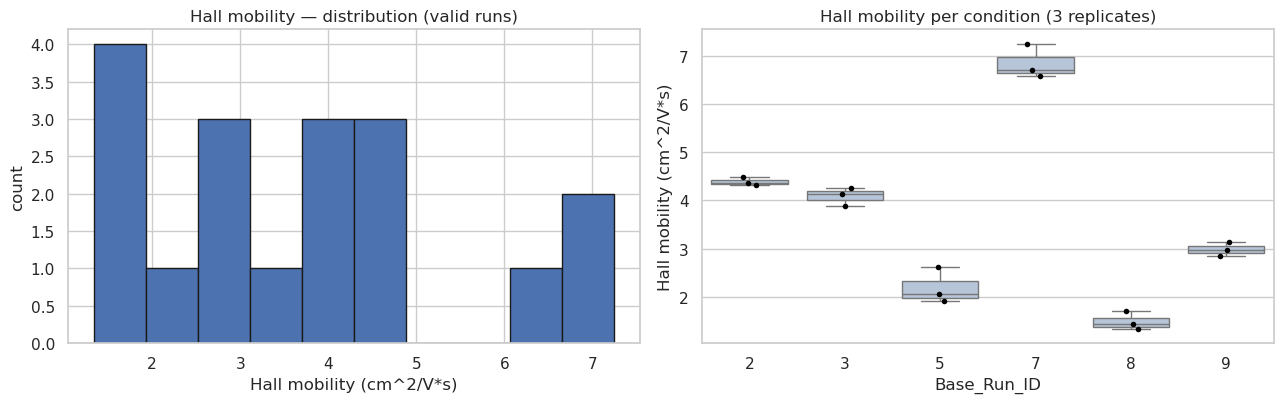

In [7]:
# Hall mobility distribution and per-condition box plot (valid measurements only).
valid = df.dropna(subset=[RESP]).copy()
print(valid[RESP].describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(valid[RESP], bins=10, edgecolor='k')
axes[0].set_title('Hall mobility — distribution (valid runs)')
axes[0].set_xlabel(RESP); axes[0].set_ylabel('count')

sns.boxplot(data=valid, x='Base_Run_ID', y=RESP, ax=axes[1], color='lightsteelblue')
sns.stripplot(data=valid, x='Base_Run_ID', y=RESP, ax=axes[1], color='black', size=4)
axes[1].set_title('Hall mobility per condition (3 replicates)')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'hall_mobility_overview.png'), dpi=200); plt.show()

In [8]:
# Condition-level summary table (valid runs).
summary = (valid.groupby('Base_Run_ID')
                .agg(n=('Replicate','count'),
                     mobility_mean=(RESP,'mean'),
                     mobility_std=(RESP,'std'),
                     mobility_min=(RESP,'min'),
                     mobility_max=(RESP,'max'),
                     carrier_mean=(CARR,'mean'))
                .round(3))
factor_lookup = df.drop_duplicates('Base_Run_ID').set_index('Base_Run_ID')[FACTORS]
summary = summary.join(factor_lookup)
summary.to_excel(os.path.join(OUT_DIR, 'condition_summary.xlsx'))
summary

,n,mobility_mean,mobility_std,mobility_min,mobility_max,carrier_mean,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm)
Base_Run_ID,,,,,,,,,,,,,,,,
2,3,4.393,0.085,4.33,4.49,1.640000e+20,28,11.5,9.7,25,476.8,0.02,14.3,155.4,18.1,5.1
3,3,4.097,0.189,3.89,4.26,1.903333e+20,40,9.1,3.4,425,262.5,0.02,71.7,400.0,57.9,2.2
5,3,2.197,0.374,1.91,2.62,5.166667e+19,19,7.0,8.5,25,661.6,1.00,82.5,288.6,31.0,3.5
7,3,6.847,0.355,6.58,7.25,5.773333e+19,23,1.6,7.3,25,364.3,0.02,118.0,474.1,117.0,8.6
8,3,1.490,0.187,1.34,1.70,1.503333e+20,8,14.2,2.6,425,594.5,1.00,26.1,48.9,14.6,1.7
9,3,2.987,0.150,2.84,3.14,5.040000e+19,7,8.7,7.6,425,429.6,1.00,81.0,229.6,42.4,9.6


### Preliminary takeaways

_The cells above produce the numbers; the bullets below are written so you can read them out loud._
- 40 % of the conditions delivered so far (4/10) failed contact, all 3 replicates each.
- The `factor_means_fail_vs_valid.xlsx` table is the quickest place to spot which knob settings cluster with failure.
- Replicate-to-replicate scatter is small for most surviving conditions — useful for ANOVA below.
- Carrier concentration is on the order of 1e+19–1e+20 cm⁻³ with a spread of ~4× across conditions.

## 3. ANOVA

With only 6 valid conditions × 3 replicates = 18 measurements and 10 factors, a full main-effects ANOVA is rank-deficient. We do two things:

1. **One-way ANOVA per factor** — each numeric factor is binned at its median into Low/High; this gives every factor an isolated F-test on Hall mobility.
2. **Replicate (between-condition) ANOVA** — confirms that condition explains variance beyond replicate noise.

Both are saved as Excel.

In [9]:
anova_rows = []
for f in FACTORS:
    x = valid[f].values
    if len(np.unique(x)) < 2:
        anova_rows.append({'factor': f, 'levels': 'constant', 'F': np.nan, 'p_value': np.nan})
        continue
    if len(np.unique(x)) == 2:
        groups = [valid.loc[valid[f]==v, RESP].values for v in np.unique(x)]
        level_label = 'binary'
    else:
        med = np.median(x)
        groups = [valid.loc[valid[f] <= med, RESP].values,
                  valid.loc[valid[f] >  med, RESP].values]
        level_label = f'split @ median={med:g}'
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        anova_rows.append({'factor': f, 'levels': level_label, 'F': np.nan, 'p_value': np.nan})
        continue
    F, p = stats.f_oneway(*groups)
    anova_rows.append({'factor': f, 'levels': level_label,
                       'n_low': len(groups[0]), 'n_high': len(groups[1]),
                       'F': round(float(F), 4), 'p_value': round(float(p), 4)})
anova_df = pd.DataFrame(anova_rows).sort_values('p_value', na_position='last')
anova_df.to_excel(os.path.join(OUT_DIR, 'anova_per_factor.xlsx'), index=False)
anova_df

,factor,levels,n_low,n_high,F,p_value
0,Dep Power (W),split @ median=21,9,9,33.7957,0.0000
5,Ox Press (atm),binary,9,9,33.7957,0.0000
9,Dep Thickness (nm),split @ median=4.3,9,9,9.6173,0.0069
4,Ox Temp (°C),split @ median=453.2,9,9,7.1704,0.0165
8,Vac Ann Time (min),split @ median=36.7,9,9,7.1704,0.0165
3,Dep Temp (°C),binary,9,9,4.3531,0.0533
7,Vac Ann Temp (°C),split @ median=259.1,9,9,3.1588,0.0945
2,Dep Press (mTorr),split @ median=7.45,9,9,1.2748,0.2755
6,Ox Time (min),split @ median=76.35,9,9,0.6321,0.4382
1,O2 Flow (sccm),split @ median=8.9,9,9,0.6321,0.4382


In [10]:
# Between-condition ANOVA: does Base_Run_ID explain variance beyond replicate noise?
model_cond = ols(f'Q("{RESP}") ~ C(Base_Run_ID)', data=valid).fit()
anova_cond = sm.stats.anova_lm(model_cond, typ=2).round(4)
anova_cond.to_excel(os.path.join(OUT_DIR, 'anova_between_conditions.xlsx'))
print(anova_cond)
print(f"R^2 (condition model): {model_cond.rsquared:.3f}")

                 sum_sq    df         F  PR(>F)
C(Base_Run_ID)  54.5595   5.0  178.5097     0.0
Residual         0.7335  12.0       NaN     NaN
R^2 (condition model): 0.987


## 4. Coefficient of variation across replicates

CV (%) = 100 × std / mean, computed per Base_Run_ID over its 3 replicates. This tells us how repeatable each condition is independent of its absolute mobility level.

In [11]:
cv_rows = []
for bid, g in valid.groupby('Base_Run_ID'):
    m = g[RESP].mean(); s = g[RESP].std()
    cv_rows.append({'Base_Run_ID': bid, 'n': len(g),
                    'mean': round(m,3), 'std': round(s,3),
                    'CV_%': round(100*s/m, 2)})
cv_df = pd.DataFrame(cv_rows).sort_values('CV_%')
cv_df.to_excel(os.path.join(OUT_DIR, 'cv_percentage.xlsx'), index=False)
print(f'Median CV: {cv_df["CV_%"].median():.2f} %  |  Max CV: {cv_df["CV_%"].max():.2f} %')
cv_df

Median CV: 5.11 %  |  Max CV: 17.04 %


,Base_Run_ID,n,mean,std,CV_%
0,2,3,4.393,0.085,1.94
1,3,3,4.097,0.189,4.61
5,9,3,2.987,0.150,5.03
3,7,3,6.847,0.355,5.19
4,8,3,1.490,0.187,12.57
2,5,3,2.197,0.374,17.04


## 5. Linear regression validation

**Caveat (important).** With 18 valid measurements (only 6 unique conditions) and 10 process factors, a full linear model is over-parameterised and replicates within a condition do not give the regression independent information about the factors. We do two cross-validations:

1. **LOO-CV at the row level** on a condition-mean dataset (n=6) using the most informative factors. Honest but very small sample.
2. **Group K-fold by condition** on the full 18-row dataset — each fold leaves out an entire condition (all 3 replicates) so the test set is not contaminated.

Both are persisted with metrics and predicted-vs-actual values.

In [12]:
# Build condition-level dataset (6 rows).
cond_df = valid.groupby('Base_Run_ID').agg({**{f:'first' for f in FACTORS}, RESP:'mean'}).reset_index()
print('Condition-level dataset:', cond_df.shape)
X_full = cond_df[FACTORS].values
y_full = cond_df[RESP].values

# Pick the top-k factors by |Pearson r| with mobility (k chosen so n - k - 1 >= 1).
ranks = []
for f in FACTORS:
    if cond_df[f].nunique() < 2:
        ranks.append((f, 0.0)); continue
    r, _ = stats.pearsonr(cond_df[f], cond_df[RESP])
    ranks.append((f, abs(r)))
ranks = sorted(ranks, key=lambda t: -t[1])
k = min(3, len(cond_df) - 2)
top_factors = [f for f, _ in ranks[:k]]
print(f'Top-{k} factors by |corr| with mobility: {top_factors}')

Xc = cond_df[top_factors].values
yc = cond_df[RESP].values
scaler = StandardScaler().fit(Xc)
Xc_s = scaler.transform(Xc)

# LOO on the 6 conditions.
loo = LeaveOneOut()
preds = np.zeros_like(yc); actuals = yc.copy()
for tr, te in loo.split(Xc_s):
    m = LinearRegression().fit(Xc_s[tr], yc[tr])
    preds[te] = m.predict(Xc_s[te])
loo_r2  = r2_score(actuals, preds)
loo_rmse = np.sqrt(mean_squared_error(actuals, preds))
loo_mae = float(np.mean(np.abs(actuals - preds)))

# Fit on all 6 to report training R^2 too.
m_full = LinearRegression().fit(Xc_s, yc)
train_r2 = m_full.score(Xc_s, yc)

loo_pred_df = pd.DataFrame({'Base_Run_ID': cond_df['Base_Run_ID'],
                            'actual_mobility': actuals,
                            'loo_predicted': preds.round(3),
                            'residual': (actuals - preds).round(3)})
print(f'LOO  R²: {loo_r2:.3f}  |  RMSE: {loo_rmse:.3f}  |  MAE: {loo_mae:.3f}')
print(f'Train R² (n={len(yc)}, k={k}): {train_r2:.3f}')
loo_pred_df

Condition-level dataset: (6, 12)
Top-3 factors by |corr| with mobility: ['Vac Ann Time (min)', 'Ox Press (atm)', 'Vac Ann Temp (°C)']
LOO  R²: 0.258  |  RMSE: 1.500  |  MAE: 1.373
Train R² (n=6, k=3): 0.937


,Base_Run_ID,actual_mobility,loo_predicted,residual
0,2,4.393333,2.179,2.214
1,3,4.096667,5.527,-1.431
2,5,2.196667,1.614,0.583
3,7,6.846667,5.259,1.588
4,8,1.490000,3.313,-1.823
5,9,2.986667,2.386,0.601


In [13]:
# Group K-fold (leave-one-condition-out) on the full 18-row dataset using the same top-k factors.
from sklearn.model_selection import LeaveOneGroupOut
X_rep = valid[top_factors].values
y_rep = valid[RESP].values
groups = valid['Base_Run_ID'].values
scaler2 = StandardScaler().fit(X_rep)
X_rep_s = scaler2.transform(X_rep)

logo = LeaveOneGroupOut()
preds_g = np.zeros_like(y_rep, dtype=float)
for tr, te in logo.split(X_rep_s, y_rep, groups):
    m = LinearRegression().fit(X_rep_s[tr], y_rep[tr])
    preds_g[te] = m.predict(X_rep_s[te])
logo_r2 = r2_score(y_rep, preds_g)
logo_rmse = np.sqrt(mean_squared_error(y_rep, preds_g))
logo_mae = float(np.mean(np.abs(y_rep - preds_g)))
print(f'LOGO R²: {logo_r2:.3f}  |  RMSE: {logo_rmse:.3f}  |  MAE: {logo_mae:.3f}')

logo_pred_df = valid[['Base_Run_ID','Replicate', RESP]].copy()
logo_pred_df['logo_predicted'] = preds_g.round(3)
logo_pred_df['residual'] = (logo_pred_df[RESP] - logo_pred_df['logo_predicted']).round(3)
logo_pred_df

LOGO R²: 0.255  |  RMSE: 1.513  |  MAE: 1.373


,Base_Run_ID,Replicate,Hall mobility (cm^2/V*s),logo_predicted,residual
3,2,1,4.36,2.179,2.181
4,2,2,4.33,2.179,2.151
5,2,3,4.49,2.179,2.311
6,3,1,3.89,5.527,-1.637
7,3,2,4.14,5.527,-1.387
8,3,3,4.26,5.527,-1.267
12,5,1,1.91,1.614,0.296
13,5,2,2.62,1.614,1.006
14,5,3,2.06,1.614,0.446
18,7,1,7.25,5.259,1.991


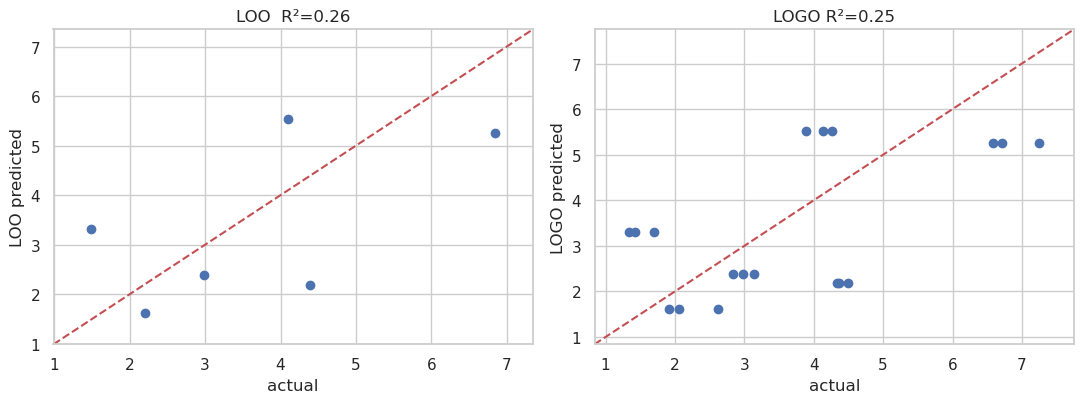

,scheme,R2,RMSE,MAE
0,"Train (condition means, n=6)",0.937,NaN,NaN
1,"LOO (condition means, n=6)",0.258,1.500,1.373
2,"LOGO (replicate-level, n=18)",0.255,1.513,1.373


In [14]:
# Save consolidated regression validation Excel.
metrics = pd.DataFrame([
    {'scheme': 'Train (condition means, n=6)', 'R2': round(train_r2,3), 'RMSE': np.nan, 'MAE': np.nan},
    {'scheme': 'LOO  (condition means, n=6)', 'R2': round(loo_r2,3), 'RMSE': round(loo_rmse,3), 'MAE': round(loo_mae,3)},
    {'scheme': 'LOGO (replicate-level, n=18)', 'R2': round(logo_r2,3), 'RMSE': round(logo_rmse,3), 'MAE': round(logo_mae,3)},
])
coefs = pd.DataFrame({'factor': top_factors,
                      'coef_standardized': m_full.coef_.round(4)})
coefs.loc[len(coefs)] = ['intercept', round(float(m_full.intercept_), 4)]

with pd.ExcelWriter(os.path.join(OUT_DIR, 'linear_regression_validation.xlsx')) as w:
    metrics.to_excel(w, sheet_name='metrics', index=False)
    coefs.to_excel(w, sheet_name='coefficients', index=False)
    loo_pred_df.to_excel(w, sheet_name='LOO_predictions', index=False)
    logo_pred_df.to_excel(w, sheet_name='LOGO_predictions', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(actuals, preds); lim = [min(actuals.min(), preds.min())-0.5, max(actuals.max(), preds.max())+0.5]
axes[0].plot(lim, lim, 'r--'); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('actual'); axes[0].set_ylabel('LOO predicted'); axes[0].set_title(f'LOO  R²={loo_r2:.2f}')
axes[1].scatter(y_rep, preds_g); lim = [min(y_rep.min(), preds_g.min())-0.5, max(y_rep.max(), preds_g.max())+0.5]
axes[1].plot(lim, lim, 'r--'); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('actual'); axes[1].set_ylabel('LOGO predicted'); axes[1].set_title(f'LOGO R²={logo_r2:.2f}')
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, 'regression_pred_vs_actual.png'), dpi=200); plt.show()
metrics

### Reading the regression results
- A negative LOO R² means the model does worse than predicting the mean. With n=6 and k=3 that is unsurprising, but it is the honest signal that we **do not yet have enough conditions to fit even a 3-factor linear model**.
- LOGO uses replicates only to stabilise the slope on training folds; the test fold is always an unseen condition, so LOGO R² is the more meaningful number for predictive use.
- The standardized coefficients in `coefficients` show direction-of-effect for the top-k factors but should not be over-interpreted at this sample size.
- All numbers above were generated from the 30 received rows (10 conditions, 6 surviving). The remaining 13 conditions of Sobol-V03 will materially change the fit.

## 6. Factor effects on Hall mobility and carrier concentration

Two complementary views:

1. **Pair plot (factor × response)** — every factor against both responses, with replicate points coloured by `Base_Run_ID`. This keeps the whole picture in one figure but stays readable because we do *not* draw factor-vs-factor panels.
2. **Per-factor effects grid** — one small panel per factor, two rows (mobility, carrier concentration), with the condition mean ± replicate std overlaid on the raw points and a fitted trend (linear for continuous factors, group means for binary factors). Easiest to scan visually.

Both use only the 6 valid (non-contact-fail) conditions × 3 replicates = 18 measurements. Carrier concentration is plotted on a log axis because it spans 4.5e+19 to 1.9e+20.

In [15]:
# Build the tidy frame the plots need.
plot_df = valid.copy()
# Categorical labels for the binary factors (nicer axes than 25/425 or 0.02/1.00).
plot_df['Dep Temp (°C)_lbl']  = plot_df['Dep Temp (°C)'].map({25.0:'25', 425.0:'425'}).fillna(plot_df['Dep Temp (°C)'].astype(str))
plot_df['Ox Press (atm)_lbl'] = plot_df['Ox Press (atm)'].map({0.02:'0.02', 1.00:'1.00'}).fillna(plot_df['Ox Press (atm)'].astype(str))

CONT_FACTORS = [f for f in FACTORS if not isinstance(PDO_CONFIG[f], list)]
CAT_FACTORS  = [f for f in FACTORS if     isinstance(PDO_CONFIG[f], list)]
RESPONSES = [(RESP, 'Hall mobility (cm²/V·s)', False),
             (CARR, 'Carrier concentration (#/cm³)', True)]
print(f'{len(CONT_FACTORS)} continuous factors + {len(CAT_FACTORS)} categorical factors')
print('Continuous:', CONT_FACTORS)
print('Categorical:', CAT_FACTORS)


8 continuous factors + 2 categorical factors
Continuous: ['Dep Power (W)', 'O2 Flow (sccm)', 'Dep Press (mTorr)', 'Ox Temp (°C)', 'Ox Time (min)', 'Vac Ann Temp (°C)', 'Vac Ann Time (min)', 'Dep Thickness (nm)']
Categorical: ['Dep Temp (°C)', 'Ox Press (atm)']


### 6.1  Pair plot — factors vs responses (no factor-vs-factor panels)

This is a `factor × response` grid: rows = the 10 process factors, columns = the 2 responses. Replicate points are coloured by condition (`Base_Run_ID`) so you can see how the 3 replicates of each condition cluster. Carrier concentration uses a log y-axis.

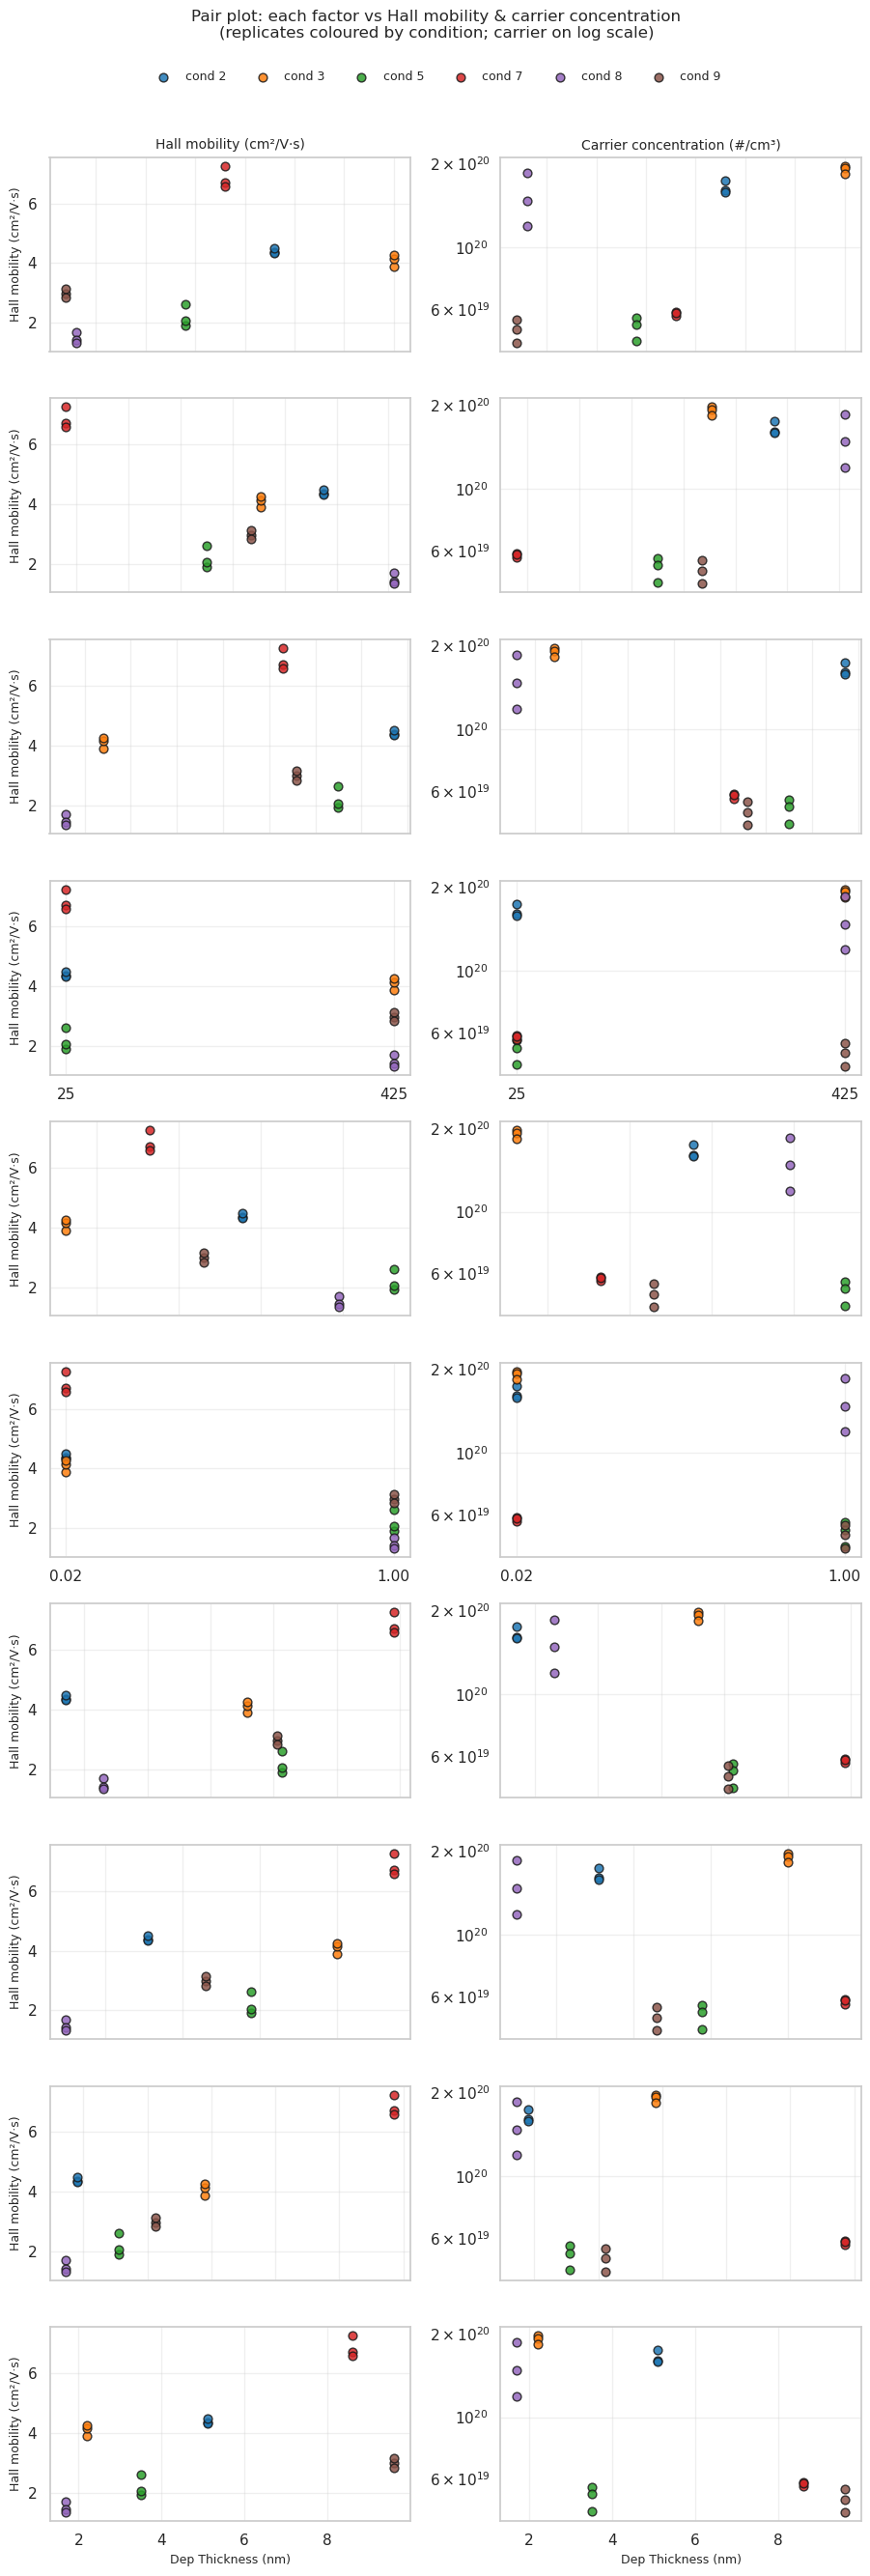

In [16]:
# 10 factors × 2 responses, replicates coloured by condition.
n_rows, n_cols = len(FACTORS), len(RESPONSES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 2.6 * n_rows), sharey=False)
palette = sns.color_palette('tab10', n_colors=plot_df['Base_Run_ID'].nunique())
cond_to_color = dict(zip(sorted(plot_df['Base_Run_ID'].unique()), palette))

for i, f in enumerate(FACTORS):
    is_cat = isinstance(PDO_CONFIG[f], list)
    xcol = f + '_lbl' if is_cat else f
    for j, (resp_col, resp_label, log_y) in enumerate(RESPONSES):
        ax = axes[i, j]
        sub = plot_df.dropna(subset=[resp_col])
        for cid, g in sub.groupby('Base_Run_ID'):
            ax.scatter(g[xcol], g[resp_col], color=cond_to_color[cid],
                       edgecolor='k', s=40, alpha=0.85, label=f'cond {cid}' if (i == 0 and j == 0) else None)
        if log_y:
            ax.set_yscale('log')
        if i == n_rows - 1:
            ax.set_xlabel(f, fontsize=9)
        else:
            ax.set_xlabel('')
            if not is_cat:
                ax.tick_params(axis='x', labelbottom=False)
        if j == 0:
            ax.set_ylabel(resp_label, fontsize=9)
        if i == 0:
            ax.set_title(resp_label, fontsize=10)
        ax.grid(True, alpha=0.3)

# Single legend at the top.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(handles), bbox_to_anchor=(0.5, 1.005), fontsize=9, frameon=False)
fig.suptitle('Pair plot: each factor vs Hall mobility & carrier concentration\n(replicates coloured by condition; carrier on log scale)', y=1.025, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'pairplot_factor_vs_response.png'), dpi=200, bbox_inches='tight')
plt.show()


### 6.2  Per-factor effects grid — easiest to read

One panel per factor, two rows of panels (top = mobility, bottom = carrier concentration). Each panel shows:

- **Grey dots** — individual replicates.
- **Black markers** — condition means with ±1 SD error bars across the 3 replicates.
- **Red dashed line** — best-fit linear trend for continuous factors (purely descriptive at n=6 conditions); for binary factors, a horizontal segment per level.

Because every panel has its own x-axis, you read each factor's effect in isolation — no factor-vs-factor coupling shown.

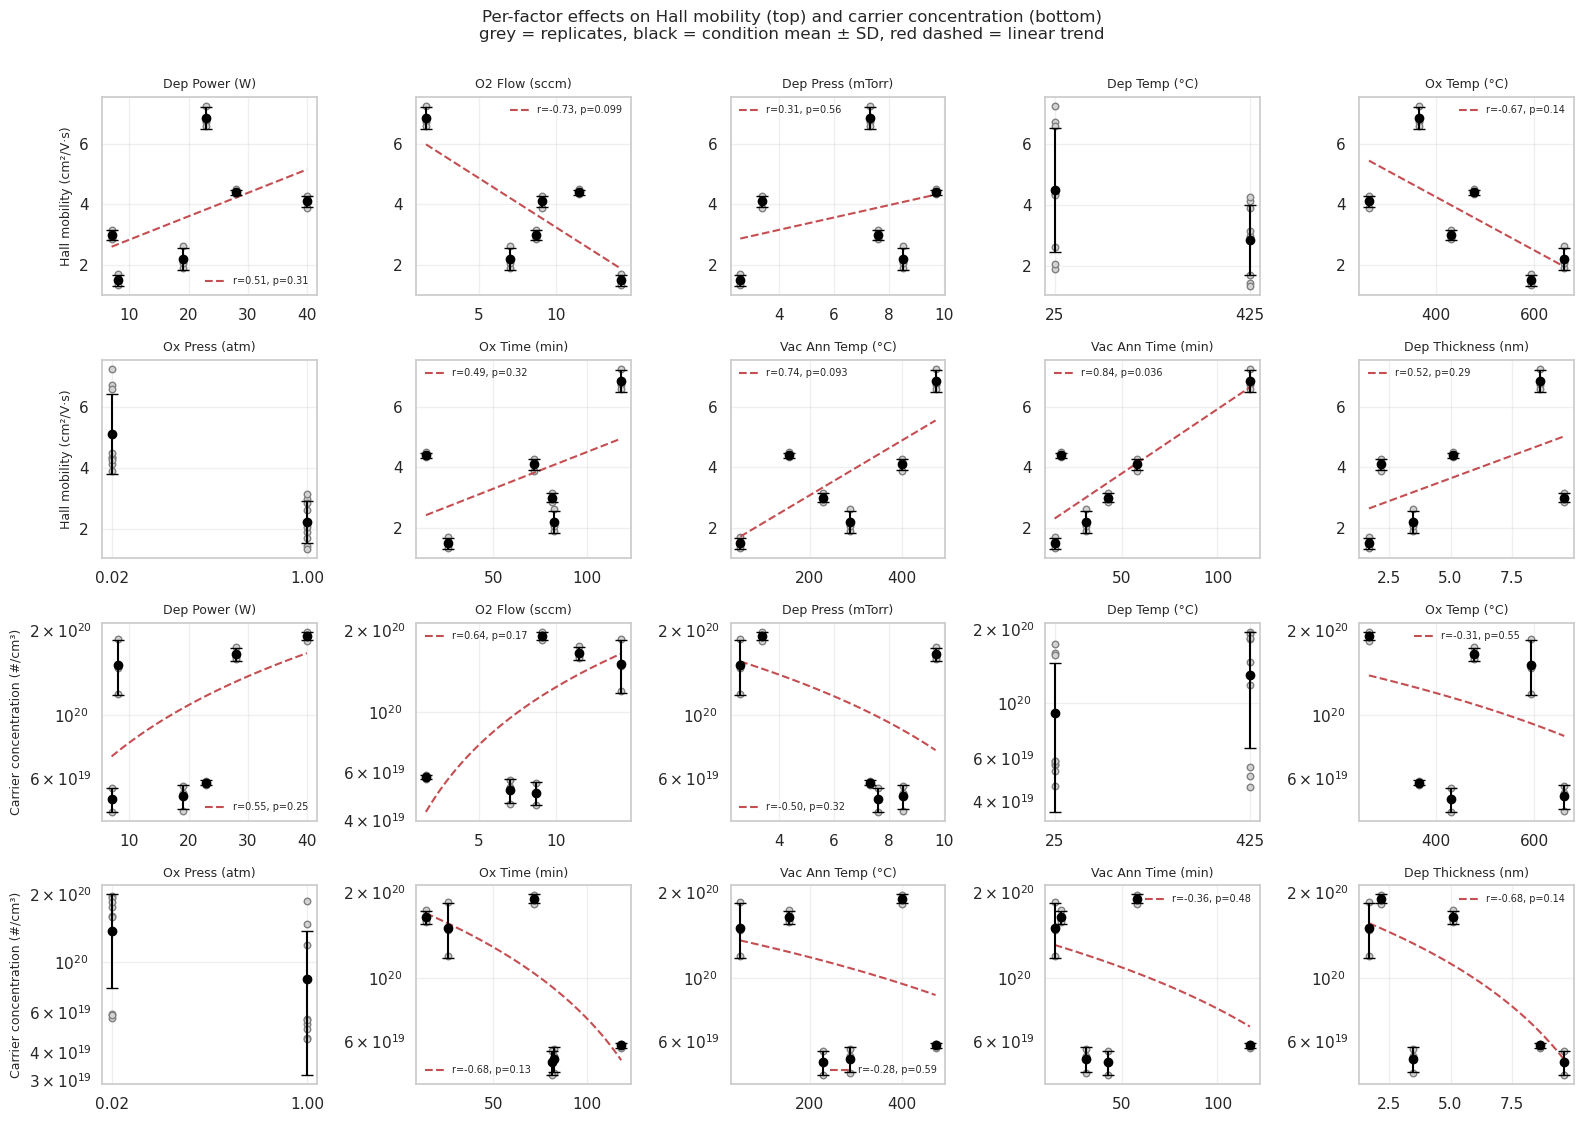

In [17]:
# Two-row grid: row 0 = mobility, row 1 = carrier concentration.
n_factors = len(FACTORS)
ncols = 5
nrows_per_resp = math.ceil(n_factors / ncols)

fig, axes = plt.subplots(2 * nrows_per_resp, ncols, figsize=(3.2 * ncols, 2.8 * 2 * nrows_per_resp))
axes = np.atleast_2d(axes)

def panel(ax, sub, fcol, ycol, log_y):
    is_cat = isinstance(PDO_CONFIG[fcol], list)
    # raw replicates
    if is_cat:
        xcol = fcol + '_lbl'
        order = sorted(sub[xcol].unique())
        for k, lvl in enumerate(order):
            v = sub.loc[sub[xcol] == lvl, ycol].values
            ax.scatter([k] * len(v), v, color='lightgray', edgecolor='gray', s=22, zorder=1)
            if len(v) > 0:
                ax.errorbar(k, np.mean(v), yerr=(np.std(v, ddof=1) if len(v) > 1 else 0),
                            fmt='o', color='black', ms=6, capsize=4, zorder=3)
        ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
    else:
        ax.scatter(sub[fcol], sub[ycol], color='lightgray', edgecolor='gray', s=22, zorder=1)
        cond_means = sub.groupby('Base_Run_ID').agg(x=(fcol, 'first'),
                                                     y_mean=(ycol, 'mean'),
                                                     y_std=(ycol, 'std')).reset_index()
        ax.errorbar(cond_means['x'], cond_means['y_mean'], yerr=cond_means['y_std'].fillna(0),
                    fmt='o', color='black', ms=6, capsize=4, zorder=3)
        # Linear trend on condition means.
        if cond_means['x'].nunique() >= 2:
            xs = np.linspace(cond_means['x'].min(), cond_means['x'].max(), 50)
            slope, intercept, r, p, _ = stats.linregress(cond_means['x'], cond_means['y_mean'])
            ax.plot(xs, intercept + slope * xs, 'r--', lw=1.5, zorder=2,
                    label=f'r={r:.2f}, p={p:.2g}')
            ax.legend(fontsize=7, loc='best', frameon=False)
    if log_y:
        ax.set_yscale('log')
    ax.set_title(fcol, fontsize=9)
    ax.grid(True, alpha=0.3)

# Top half: mobility; bottom half: carrier concentration.
for resp_idx, (resp_col, resp_label, log_y) in enumerate(RESPONSES):
    sub = plot_df.dropna(subset=[resp_col])
    for k, fcol in enumerate(FACTORS):
        r = resp_idx * nrows_per_resp + (k // ncols)
        c = k % ncols
        panel(axes[r, c], sub, fcol, resp_col, log_y)
        if c == 0:
            axes[r, c].set_ylabel(resp_label, fontsize=9)
    # Hide unused panels in this response's rows.
    used = n_factors
    for k in range(used, nrows_per_resp * ncols):
        r = resp_idx * nrows_per_resp + (k // ncols)
        c = k % ncols
        axes[r, c].set_visible(False)

fig.suptitle('Per-factor effects on Hall mobility (top) and carrier concentration (bottom)\n'
             'grey = replicates, black = condition mean ± SD, red dashed = linear trend',
             y=1.0, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'per_factor_effects.png'), dpi=200, bbox_inches='tight')
plt.show()


In [18]:
# Save Pearson r and p for every continuous factor against both responses, so the
# numbers behind the red dashed lines are stored alongside the picture.
rows = []
for fcol in CONT_FACTORS:
    for (resp_col, resp_label, _) in RESPONSES:
        cond_means = plot_df.dropna(subset=[resp_col]).groupby('Base_Run_ID').agg(
            x=(fcol, 'first'), y=(resp_col, 'mean')).reset_index()
        if cond_means['x'].nunique() < 2:
            rows.append({'factor': fcol, 'response': resp_label, 'pearson_r': np.nan,
                         'p_value': np.nan, 'slope_per_unit': np.nan, 'n_conditions': len(cond_means)})
            continue
        slope, intercept, r, p, _ = stats.linregress(cond_means['x'], cond_means['y'])
        rows.append({'factor': fcol, 'response': resp_label,
                     'pearson_r': round(float(r), 3), 'p_value': round(float(p), 4),
                     'slope_per_unit': float(f'{slope:.3g}'), 'n_conditions': len(cond_means)})
# Binary factors: report difference of means.
for fcol in CAT_FACTORS:
    for (resp_col, resp_label, _) in RESPONSES:
        sub = plot_df.dropna(subset=[resp_col])
        groups = [sub.loc[sub[fcol] == lvl, resp_col].values for lvl in sorted(sub[fcol].unique())]
        if len(groups) < 2 or any(len(g) == 0 for g in groups):
            rows.append({'factor': fcol, 'response': resp_label, 'pearson_r': np.nan,
                         'p_value': np.nan, 'slope_per_unit': np.nan, 'n_conditions': sum(map(len, groups))})
            continue
        F, p = stats.f_oneway(*groups)
        rows.append({'factor': fcol, 'response': resp_label,
                     'pearson_r': np.nan, 'p_value': round(float(p), 4),
                     'slope_per_unit': f'mean_high - mean_low = {np.mean(groups[1]) - np.mean(groups[0]):.3g}',
                     'n_conditions': sub['Base_Run_ID'].nunique()})

effect_df = pd.DataFrame(rows)
effect_df.to_excel(os.path.join(OUT_DIR, 'factor_effects_summary.xlsx'), index=False)
effect_df


,factor,response,pearson_r,p_value,slope_per_unit,n_conditions
0,Dep Power (W),Hall mobility (cm²/V·s),0.506,0.3058,0.0771,6
1,Dep Power (W),Carrier concentration (#/cm³),0.554,0.2545,2850000000000000000.0,6
2,O2 Flow (sccm),Hall mobility (cm²/V·s),-0.731,0.0985,-0.326,6
3,O2 Flow (sccm),Carrier concentration (#/cm³),0.636,0.1744,9560000000000000000.0,6
4,Dep Press (mTorr),Hall mobility (cm²/V·s),0.306,0.5558,0.204,6
5,Dep Press (mTorr),Carrier concentration (#/cm³),-0.498,0.3152,-11200000000000000000.0,6
6,Ox Temp (°C),Hall mobility (cm²/V·s),-0.675,0.1414,-0.00876,6
7,Ox Temp (°C),Carrier concentration (#/cm³),-0.307,0.5541,-134000000000000000.0,6
8,Ox Time (min),Hall mobility (cm²/V·s),0.495,0.3186,0.0244,6
9,Ox Time (min),Carrier concentration (#/cm³),-0.684,0.1341,-1140000000000000000.0,6


## 7. Sobol Batch 2 with temperature caps

The 4 failed conditions in Batch 1 share a clear signal: every failure had `Vac Ann Temp (°C) > 580` (584, 620, 655, 728), while every surviving condition had `Vac Ann Temp (°C) ≤ 474`. `Ox Temp` is less cleanly separated but the highest values (732, 774, 791) are mostly in failed or untested runs.

Sobol sequences support **incremental extension**: continuing the same `qmc.Sobol` instance past Batch 1 keeps the cumulative point set low-discrepancy in the original 10-D unit hypercube. We exploit this two ways:

1. **Continue the same sequence** (do *not* re-seed) so Batch 2's 23 points fill the gaps left by Batch 1.
2. **Cap the high-temperature mappings** by reducing the upper bound of `Ox Temp (°C)` and `Vac Ann Temp (°C)` in the parameter map for Batch 2. The Sobol u-values still cover [0, 1] uniformly; only the affine scaling to °C changes.

Caveat: shrinking the bound changes the search domain for those two factors, so Batch 1 + Batch 2 together are no longer a single uniform Sobol design over the original box — they are uniform over a *truncated* box for the two capped factors. This is the right trade given that the upper region wasn't yielding measurable devices anyway.


In [19]:
# --- Batch 2 configuration: continue Sobol, cap temperatures ---
B2_OX_TEMP_MAX      = 600.0   # was 800
B2_VAC_ANN_TEMP_MAX = 600.0   # was 800
N_BATCH2 = 23

PDO_CONFIG_B2 = {**PDO_CONFIG}  # shallow copy, then overwrite the two capped factors
PDO_CONFIG_B2['Ox Temp (°C)']      = {'min': 200.0, 'max': B2_OX_TEMP_MAX,      'decimals': 1}
PDO_CONFIG_B2['Vac Ann Temp (°C)'] = {'min':  25.0, 'max': B2_VAC_ANN_TEMP_MAX, 'decimals': 1}

# Reconstruct the Sobol sampler with the same seed AND advance it past the points
# already consumed by Batch 1 (we used `random(n=23*5)=115` draws to produce 23 rows).
# This keeps the cumulative design low-discrepancy in the unit hypercube.
sampler_b2 = qmc.Sobol(d=len(PDO_CONFIG_B2), scramble=True, seed=GLOBAL_SEED)
_ = sampler_b2.random(n=N_BATCH2 * 5)   # burn the same number of draws Batch 1 consumed

# Generate Batch 2 from the continued sequence
df_pdo_b2_plan, _ = generate_doe(N_BATCH2, PDO_CONFIG_B2, sampler=sampler_b2, seed=None)
df_pdo_b2_plan['Batch'] = 'Batch 2'
df_pdo_b2_full = add_replicates(df_pdo_b2_plan, NUM_REPLICATES)

print(f'Batch 2 generated: {df_pdo_b2_full.shape[0]} rows ({N_BATCH2} conditions × {NUM_REPLICATES} replicates)')
print(f'Ox Temp range  : [{df_pdo_b2_plan["Ox Temp (°C)"].min():.1f}, {df_pdo_b2_plan["Ox Temp (°C)"].max():.1f}]  (cap = {B2_OX_TEMP_MAX})')
print(f'Vac Ann range  : [{df_pdo_b2_plan["Vac Ann Temp (°C)"].min():.1f}, {df_pdo_b2_plan["Vac Ann Temp (°C)"].max():.1f}]  (cap = {B2_VAC_ANN_TEMP_MAX})')
df_pdo_b2_plan.head()


Batch 2 generated: 69 rows (23 conditions × 3 replicates)
Ox Temp range  : [211.2, 579.1]  (cap = 600.0)
Vac Ann range  : [34.7, 598.7]  (cap = 600.0)


,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch
0,10.0,10.6,6.1,425.0,394.5,1.00,115.9,445.3,84.6,8.2,Batch 2
1,15.0,0.7,9.0,425.0,319.5,1.00,8.7,34.7,50.5,4.6,Batch 2
2,31.0,12.8,5.0,25.0,453.5,0.02,104.2,366.2,66.2,7.0,Batch 2
3,22.0,5.4,7.8,425.0,522.7,0.02,42.1,472.2,97.5,9.7,Batch 2
4,7.0,18.1,2.2,25.0,251.2,1.00,70.3,215.1,25.6,2.9,Batch 2


In [20]:
# --- Distribution quality: Batch 1 alone, Batch 2 alone, Batch 1 + 2 cumulative ---
from scipy.spatial.distance import pdist

def normalise_for_metrics(df_in, config):
    cols = [c for c in df_in.columns if c in config]
    M = df_in[cols].copy().astype(float)
    for c in cols:
        if isinstance(config[c], list):
            uniq = sorted(set(config[c]))
            M[c] = M[c].map({v: i/(len(uniq)-1) if len(uniq) > 1 else 0.0 for i, v in enumerate(uniq)})
        else:
            lo, hi = config[c]['min'], config[c]['max']
            M[c] = (M[c] - lo) / (hi - lo) if hi > lo else 0.0
    return np.clip(M.values, 0.0, 1.0)

# Use the *Batch 2* (capped) bounds to evaluate cumulative quality, since Batch 1 lives
# inside the smaller box too — its Vac Ann/Ox Temp values that exceeded 600 are the
# failed runs we are intentionally avoiding going forward. We mark how many fall outside.
b1_plan = df_pdo_plan_full.drop_duplicates('Base_Run_ID')[FACTORS]
b2_plan = df_pdo_b2_full.drop_duplicates('Base_Run_ID')[FACTORS]
cum_plan = pd.concat([b1_plan, b2_plan], ignore_index=True)

b1_outside_cap = ((b1_plan['Ox Temp (°C)']      > B2_OX_TEMP_MAX) |
                  (b1_plan['Vac Ann Temp (°C)'] > B2_VAC_ANN_TEMP_MAX)).sum()

metric_rows = []
for label, frame in [('Batch 1 (23 conds, original bounds)', b1_plan),
                     ('Batch 2 (23 conds, capped bounds)',  b2_plan),
                     ('Batch 1 + Batch 2 cumulative',       cum_plan)]:
    M = normalise_for_metrics(frame, PDO_CONFIG_B2)
    disc = qmc.discrepancy(M)
    md  = pdist(M).min() if len(M) > 1 else np.nan
    metric_rows.append({'design': label, 'n_conditions': len(frame),
                        'discrepancy': round(float(disc), 4),
                        'min_pairwise_dist': round(float(md), 4)})
metrics_b2 = pd.DataFrame(metric_rows)
metrics_b2.to_excel(os.path.join(OUT_DIR, 'sobol_batch2_metrics.xlsx'), index=False)
print(f'Batch 1 conditions exceeding the new caps: {b1_outside_cap} / {len(b1_plan)}')
metrics_b2


Batch 1 conditions exceeding the new caps: 10 / 23


,design,n_conditions,discrepancy,min_pairwise_dist
0,"Batch 1 (23 conds, original bounds)",23,0.7819,0.7269
1,"Batch 2 (23 conds, capped bounds)",23,0.6459,0.7666
2,Batch 1 + Batch 2 cumulative,46,0.5481,0.5318


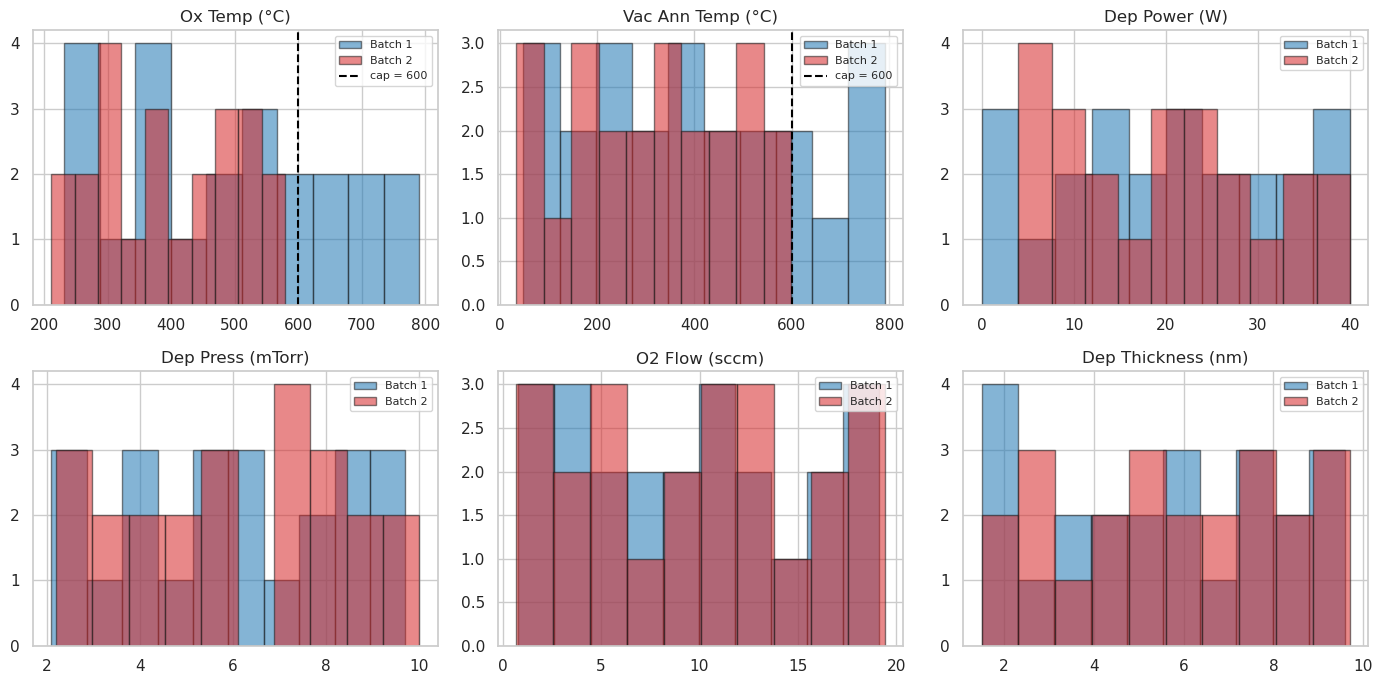

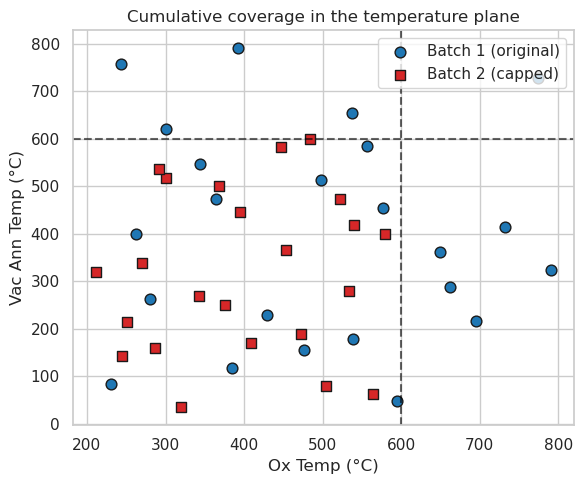

In [21]:
# --- Visualise distributions: Batch 1 vs Batch 2 ---
plot_factors = ['Ox Temp (°C)', 'Vac Ann Temp (°C)', 'Dep Power (W)',
                'Dep Press (mTorr)', 'O2 Flow (sccm)', 'Dep Thickness (nm)']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, f in zip(axes.flat, plot_factors):
    ax.hist(b1_plan[f], bins=10, alpha=0.55, label='Batch 1', color='#1f77b4', edgecolor='k')
    ax.hist(b2_plan[f], bins=10, alpha=0.55, label='Batch 2', color='#d62728', edgecolor='k')
    if f == 'Ox Temp (°C)':
        ax.axvline(B2_OX_TEMP_MAX, ls='--', color='black', label=f'cap = {B2_OX_TEMP_MAX:g}')
    if f == 'Vac Ann Temp (°C)':
        ax.axvline(B2_VAC_ANN_TEMP_MAX, ls='--', color='black', label=f'cap = {B2_VAC_ANN_TEMP_MAX:g}')
    ax.set_title(f); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'batch2_distributions.png'), dpi=200)
plt.show()

# Cumulative scatter on the two capped factors — shows how Batch 2 fills the low-T region.
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(b1_plan['Ox Temp (°C)'], b1_plan['Vac Ann Temp (°C)'],
           c='#1f77b4', edgecolor='k', s=60, label='Batch 1 (original)')
ax.scatter(b2_plan['Ox Temp (°C)'], b2_plan['Vac Ann Temp (°C)'],
           c='#d62728', edgecolor='k', s=60, marker='s', label='Batch 2 (capped)')
ax.axvline(B2_OX_TEMP_MAX,      ls='--', color='black', alpha=0.6)
ax.axhline(B2_VAC_ANN_TEMP_MAX, ls='--', color='black', alpha=0.6)
ax.set_xlabel('Ox Temp (°C)'); ax.set_ylabel('Vac Ann Temp (°C)')
ax.set_title('Cumulative coverage in the temperature plane')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'batch2_temp_coverage.png'), dpi=200)
plt.show()


In [22]:
# --- Export Batch 2 design (and the cumulative plan) for fabrication ---
b2_path = os.path.join(OUT_DIR, 'PdO_DoE_Batch2_capped.xlsx')
df_b1_with_label = df_pdo_plan_full.copy()
df_b1_with_label['Batch'] = 'Batch 1'
df_cum = pd.concat([df_b1_with_label, df_pdo_b2_full], ignore_index=True)
df_cum['Cumulative_Run_ID'] = df_cum.groupby(['Batch','Base_Run_ID']).ngroup() + 1

with pd.ExcelWriter(b2_path) as w:
    df_pdo_b2_full.to_excel(w, sheet_name='Batch2_full',     index=False)
    df_pdo_b2_plan.to_excel(w, sheet_name='Batch2_unique',   index=False)
    df_cum.to_excel       (w, sheet_name='Batch1_plus_2',    index=False)
    metrics_b2.to_excel   (w, sheet_name='design_metrics',   index=False)
    pd.DataFrame([
        {'parameter': 'Ox Temp (°C) max',      'Batch 1': 800.0, 'Batch 2': B2_OX_TEMP_MAX},
        {'parameter': 'Vac Ann Temp (°C) max', 'Batch 1': 800.0, 'Batch 2': B2_VAC_ANN_TEMP_MAX},
        {'parameter': 'seed',                  'Batch 1': GLOBAL_SEED, 'Batch 2': GLOBAL_SEED},
        {'parameter': 'sampler continued',     'Batch 1': '—', 'Batch 2': 'yes (advanced past Batch 1 draws)'},
    ]).to_excel(w, sheet_name='config_diff', index=False)
print(f'Saved: {b2_path}')
df_pdo_b2_plan


Saved: output/experiment02/PdO_DoE_Batch2_capped.xlsx


,Dep Power (W),O2 Flow (sccm),Dep Press (mTorr),Dep Temp (°C),Ox Temp (°C),Ox Press (atm),Ox Time (min),Vac Ann Temp (°C),Vac Ann Time (min),Dep Thickness (nm),Batch
0,10.0,10.6,6.1,425.0,394.5,1.00,115.9,445.3,84.6,8.2,Batch 2
1,15.0,0.7,9.0,425.0,319.5,1.00,8.7,34.7,50.5,4.6,Batch 2
2,31.0,12.8,5.0,25.0,453.5,0.02,104.2,366.2,66.2,7.0,Batch 2
3,22.0,5.4,7.8,425.0,522.7,0.02,42.1,472.2,97.5,9.7,Batch 2
4,7.0,18.1,2.2,25.0,251.2,1.00,70.3,215.1,25.6,2.9,Batch 2
5,8.0,5.2,7.1,25.0,564.7,1.00,6.9,62.8,53.9,8.5,Batch 2
6,23.0,12.2,2.9,425.0,211.2,0.02,91.2,320.2,70.1,1.9,Batch 2
7,35.0,9.7,8.2,25.0,368.1,0.02,32.4,500.3,94.1,3.6,Batch 2
8,19.0,17.3,5.8,425.0,409.2,1.00,64.3,169.0,21.6,5.7,Batch 2
9,14.0,7.5,3.1,425.0,484.2,1.00,50.7,598.7,113.0,2.6,Batch 2


### How to read these results

- `sobol_batch2_metrics.xlsx` reports **discrepancy** (lower = better space-filling) and **min pairwise distance** (higher = better separation) under the same normalisation. Compare Batch 1 alone, Batch 2 alone, and the cumulative design.
- `batch2_distributions.png` shows that the capped Sobol sampler still spreads `Ox Temp` and `Vac Ann Temp` uniformly inside the smaller [200, 600] / [25, 600] windows — it does not pile up at the cap.
- `batch2_temp_coverage.png` overlays Batch 1 and Batch 2 in the (Ox Temp, Vac Ann Temp) plane to show the cumulative coverage.
- `PdO_DoE_Batch2_capped.xlsx` contains the new 23 conditions × 3 replicates, plus a `Batch1_plus_2` sheet with cumulative IDs ready to hand to the fabrication side.

If a different cap is wanted (say, 550 °C on Vac Ann Temp because run 2 at 155 was best), change `B2_OX_TEMP_MAX` / `B2_VAC_ANN_TEMP_MAX` and re-run this section — nothing upstream needs to change.


## Output files written

All under `repository_dmref/output/experiment02/`:
- `sobol_v03_completion.xlsx` — plan vs received counts, completion %.
- `factor_means_fail_vs_valid.xlsx` — mean factor settings stratified by contact-fail outcome.
- `condition_summary.xlsx` — per-condition mobility statistics joined with factor settings.
- `anova_per_factor.xlsx` — one-way ANOVA F/p for each factor (median split).
- `anova_between_conditions.xlsx` — ANOVA Base_Run_ID effect (replicate noise vs condition).
- `cv_percentage.xlsx` — per-condition coefficient of variation across replicates.
- `linear_regression_validation.xlsx` — metrics, coefficients, LOO and LOGO predictions.
- `hall_mobility_overview.png`, `regression_pred_vs_actual.png` — plots.
- `sobol_batch2_metrics.xlsx` — discrepancy and min-pairwise-distance for Batch 1, Batch 2, cumulative.
- `PdO_DoE_Batch2_capped.xlsx` — the 23 new Batch 2 conditions (with replicates), the cumulative Batch 1+2 plan, design metrics, and the config diff.
- `batch2_distributions.png`, `batch2_temp_coverage.png` — Batch 1 vs Batch 2 visual comparison.
- `pairplot_factor_vs_response.png` — every factor against both responses (replicates coloured by condition).
- `per_factor_effects.png` — per-factor effect grid (mobility on top, carrier concentration on bottom).
- `factor_effects_summary.xlsx` — Pearson r / p per factor for both responses; for binary factors, mean-difference between levels.
